# DroneCare AI - ANN Predictive Maintenance

This notebook trains and evaluates the ANN model used by the DroneCare Streamlit
application. It replaces an earlier version that was found, during a technical
audit, to compute several preprocessing/feature-selection statistics on the
**full** dataset (including rows that later ended up in the test split).

**Methodology used in this version:**

```
RAW DATA
  -> initial, non-data-dependent cleaning (dedupe, deterministic mappings)
  -> TRAIN / TEST SPLIT
  -> preprocessing (imputation, outlier bounds, categorical encoders) FIT ON TRAIN ONLY, applied to both
  -> feature selection using TRAIN-ONLY correlation with the target
  -> scaling FIT ON TRAIN ONLY
  -> SMOTE on TRAIN ONLY
  -> model training / hyperparameter search (SMOTE re-applied inside each CV fold)
  -> ONE final evaluation on the untouched TEST set
```

The test set is never used to impute values, fit encoders/scalers, select
features, or choose a winning hyperparameter configuration -- it is touched
exactly once, at the end, to report final metrics.


## PART 1: IMPORTS AND REPRODUCIBILITY SETUP

In [1]:
import os
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, ParameterGrid
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import shap

# ---- Reproducibility ----
SEED = 42
tf.keras.utils.set_random_seed(SEED)   # seeds Python's random, NumPy, and TensorFlow together
os.environ['PYTHONHASHSEED'] = str(SEED)

pd.set_option('display.max_columns', 25)
print("TensorFlow:", tf.__version__)
print("Random seed fixed at", SEED)


TensorFlow: 2.21.0
Random seed fixed at 42


## PART 2: LOAD RAW DATA

In [2]:
FILENAME = 'Supplemental Drone Telemetry Data - Drone Operations Log _test11.csv'

df_raw = pd.read_csv(FILENAME, on_bad_lines='skip')
df_raw.rename(columns={'Dstance Flown (km)': 'Distance Flown (km)'}, inplace=True)

print(f"Raw shape: {df_raw.shape}")
df_raw.info()
df_raw.head()


Raw shape: (556, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Drone ID                   555 non-null    object 
 1   Application                555 non-null    object 
 2   Drone Size                 555 non-null    object 
 3   Drone Model                555 non-null    object 
 4   Manufacturer               555 non-null    object 
 5   Propeller Count            555 non-null    float64
 6   Max Carry Weight (kg)      555 non-null    float64
 7   Actual Carry Weight (kg)   553 non-null    float64
 8   Payload Type               555 non-null    object 
 9   Payload Description        555 non-null    object 
 10  Altitude (meters)          555 non-null    float64
 11  Flight Duration (minutes)  553 non-null    float64
 12  Distance Flown (km)        555 non-null    float64
 13  Operator ID                55

,Drone ID,Application,Drone Size,Drone Model,Manufacturer,Propeller Count,Max Carry Weight (kg),Actual Carry Weight (kg),Payload Type,Payload Description,Altitude (meters),Flight Duration (minutes),Distance Flown (km),Operator ID,Flight Date,Battery Remaining (%),GPS Accuracy (meters),Wind Speed (m/s),Obstacles Encountered,Flight Status
0,D001,Package Delivery,Medium,FlyHigh 300,AeroCorp,4.0,5.0,4.7,Package,Small consumer goods,90.0,35.0,12.0,OP001,3/20/2025,22.0,4.8,8.1,Yes,Landed Unexpectedly
1,D002,Infrastructure Inspection,Large,Inspecta X,SkyView Inc.,6.0,15.0,14.2,"Camera, Sensor","High-resolution camera, thermal sensor",150.0,55.0,18.0,OP002,3/21/2025,21.0,5.6,9.0,Yes,Landed Unexpectedly
2,D003,Agricultural Spraying,Large,CropMaster,AgriDrones,8.0,20.0,21.2,Liquid Tank,Pesticide solution,45.0,44.0,14.0,OP003,3/22/2025,19.0,6.1,8.7,Yes,Landed Unexpectedly
3,D004,Aerial Photography,Small,SnapShot Mini,PhotoFly,4.0,1.0,0.9,Camera,Lightweight action camera,100.0,28.0,7.0,OP004,3/23/2025,18.0,5.9,7.4,Yes,Landed Unexpectedly
4,D005,Surveillance,Medium,Watcher Pro,SecureTech,4.0,7.0,3.0,"Camera, Sensor","Infrared camera, motion detection sensor",100.0,72.0,12.0,OP005,3/24/2025,28.0,3.9,6.1,Yes,Landed Unexpectedly


## PART 3: INITIAL, NON-DATA-DEPENDENT CLEANING

Only operations that do not rely on any distributional statistic (mean,
median, IQR, encoder vocabulary) happen before the split:
- exact-duplicate row removal (row-level equality only),
- a fixed Yes/No -> 1/0 mapping,
- a fixed target-label mapping.

None of these can leak information about which rows will later fall into the
test split.


In [3]:
df = df_raw.copy()

before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Removed {before - len(df)} exact duplicate rows -> {len(df)} rows remain")

df['Obstacles Encountered'] = df['Obstacles Encountered'].map({'Yes': 1, 'No': 0})

TARGET_MAP = {'Completed': 0, 'Landed Unexpectedly': 1}
df = df[df['Flight Status'].isin(TARGET_MAP.keys())].reset_index(drop=True)
df['Flight Status_original'] = df['Flight Status']
df['Flight Status'] = df['Flight Status'].map(TARGET_MAP)

print(df['Flight Status_original'].value_counts())


Removed 16 exact duplicate rows -> 540 rows remain
Flight Status_original
Completed              406
Landed Unexpectedly    133
Name: count, dtype: int64


## PART 4: TRAIN / TEST SPLIT (performed BEFORE any leakage-prone step)

Everything after this cell -- imputation, outlier clipping, categorical
encoding, feature selection, scaling, SMOTE, hyperparameter search -- is fit
on `X_train_raw` / `y_train` only. `X_test_raw` / `y_test` are held out
untouched until the final evaluation of each model.


In [4]:
X_full = df.drop(columns=['Flight Status', 'Flight Status_original'])
y_full = df['Flight Status']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=SEED, stratify=y_full
)
X_train_raw = X_train_raw.reset_index(drop=True)
X_test_raw = X_test_raw.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print(f"Train rows: {len(X_train_raw)}   Test rows: {len(X_test_raw)}")
print("\nTrain class balance:")
print(y_train.value_counts(normalize=True).rename('proportion'))
print("\nTest class balance:")
print(y_test.value_counts(normalize=True).rename('proportion'))


Train rows: 431   Test rows: 108

Train class balance:
Flight Status
0    0.75406
1    0.24594
Name: proportion, dtype: float64

Test class balance:
Flight Status
0    0.75
1    0.25
Name: proportion, dtype: float64


## PART 5: PREPROCESSING -- FIT ON TRAIN ONLY, APPLIED TO TRAIN AND TEST

### 5a. Missing-value imputation
Medians (numeric) and modes (categorical) are computed on `X_train_raw` only,
then used to fill missing values in **both** splits.


In [5]:
numeric_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_all = X_train_raw.select_dtypes(include=['object']).columns.tolist()

train_medians = X_train_raw[numeric_cols].median()
X_train_raw[numeric_cols] = X_train_raw[numeric_cols].fillna(train_medians)
X_test_raw[numeric_cols] = X_test_raw[numeric_cols].fillna(train_medians)

train_modes = {c: X_train_raw[c].mode().iloc[0] for c in categorical_cols_all if not X_train_raw[c].mode().empty}
for c, m in train_modes.items():
    X_train_raw[c] = X_train_raw[c].fillna(m)
    X_test_raw[c] = X_test_raw[c].fillna(m)

print("Remaining missing values -- train:", X_train_raw.isnull().sum().sum(),
      " test:", X_test_raw.isnull().sum().sum())


Remaining missing values -- train: 0  test: 0


### 5b. Outlier bounds (IQR)
Q1/Q3/IQR bounds are computed on `X_train_raw` only, then the *same* bounds
are used to clip both splits.

IQR-based clipping is only meaningful for genuinely continuous columns.
Binary/indicator columns (e.g. `Obstacles Encountered`, encoded 0/1) are
heavily skewed by construction, so Q1 and Q3 can both land on the same
value, making IQR = 0 and the resulting clip bounds `[0, 0]` -- which would
silently collapse the entire column to a single constant and destroy its
signal. Such zero-IQR columns are therefore left unclipped, and this is
reported explicitly rather than silently applied.


In [6]:
outlier_bounds = {}
skipped_zero_iqr = []
for col in numeric_cols:
    q1, q3 = X_train_raw[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0:
        skipped_zero_iqr.append(col)
        continue
    outlier_bounds[col] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)

for col, (lo, hi) in outlier_bounds.items():
    X_train_raw[col] = X_train_raw[col].clip(lo, hi)
    X_test_raw[col] = X_test_raw[col].clip(lo, hi)

print(f"Outlier bounds computed and applied on {len(outlier_bounds)} numeric columns using the TRAINING split only.")
if skipped_zero_iqr:
    print(f"Skipped clipping for {skipped_zero_iqr} -- IQR was 0 on the training split "
          "(would have collapsed the column to a constant instead of removing genuine outliers).")


Outlier bounds computed and applied on 9 numeric columns using the TRAINING split only.
Skipped clipping for ['Obstacles Encountered'] -- IQR was 0 on the training split (would have collapsed the column to a constant instead of removing genuine outliers).


### 5c. Categorical encoding -- fit on TRAIN only, with safe handling of unseen TEST categories

Only the categorical columns actually used as model inputs by the Streamlit
app are encoded (`Drone Size`, `Drone Model`, `Payload Type`, `Application`).
Row identifiers / administrative fields (`Drone ID`, `Operator ID`,
`Flight Date`) and high-cardinality free text (`Manufacturer`,
`Payload Description` -- 126 distinct values across 556 rows) are **not**
encoded at all: they were never used as model features, and blindly encoding
them only produced noise in the earlier version's EDA.

Each `LabelEncoder` is fit on the training split's categories only. If the
test split contains a category value the encoder never saw during training,
it is mapped to the **most frequent training category** for that column
(a value derived entirely from TRAIN data) instead of crashing or silently
leaking test-set information into the encoder.


In [7]:
MODEL_CATEGORICAL_COLS = ['Drone Size', 'Drone Model', 'Payload Type', 'Application']

encoders = {}
unseen_report = {}

for col in MODEL_CATEGORICAL_COLS:
    train_series = X_train_raw[col].astype(str)
    test_series = X_test_raw[col].astype(str)

    le = LabelEncoder()
    le.fit(train_series)
    encoders[col] = le

    known = set(le.classes_)
    unseen_values = sorted(set(test_series[~test_series.isin(known)].unique()))
    unseen_report[col] = unseen_values

    fallback_label = train_series.mode().iloc[0]

    X_train_raw[col] = le.transform(train_series)
    safe_test_series = test_series.apply(lambda v: v if v in known else fallback_label)
    X_test_raw[col] = le.transform(safe_test_series)

for col, vals in unseen_report.items():
    if vals:
        print(f"[safe-encoding] '{col}': {len(vals)} TEST category value(s) not seen in TRAIN, "
              f"mapped to the most frequent TRAIN category -> {vals}")
    else:
        print(f"[safe-encoding] '{col}': every TEST category was already present in TRAIN.")


[safe-encoding] 'Drone Size': every TEST category was already present in TRAIN.


[safe-encoding] 'Drone Model': every TEST category was already present in TRAIN.
[safe-encoding] 'Payload Type': 1 TEST category value(s) not seen in TRAIN, mapped to the most frequent TRAIN category -> ['Communication Device']
[safe-encoding] 'Application': every TEST category was already present in TRAIN.


## PART 6: FEATURE SELECTION USING TRAINING DATA ONLY

Correlation with the target is computed on the **training split only**. The
candidate pool intentionally excludes:
- pure row identifiers / administrative metadata (`Drone ID`, `Operator ID`,
  `Flight Date`) and redundant / high-cardinality free text (`Manufacturer`,
  `Payload Description` -- 126 distinct values across 556 rows), which carry
  no repeatable physical or operational meaning;
- **`Flight Duration (minutes)`**, which, despite having a non-trivial
  correlation with the target, is only known **after** a flight completes.
  It cannot be entered by an operator planning a mission, and the deployed
  Streamlit app's "Manual Input" form has no such field. Including it would
  make the model appear more accurate in offline evaluation while being
  useless for the app's actual pre-flight prediction workflow, so it is
  excluded from the candidate pool a priori, on operational-availability
  grounds, rather than by post-hoc statistical comparison.

The remaining candidate pool is exactly the application's 13 current input
fields. The ranking below is still genuinely computed on the training split
(not assumed to reproduce the existing list) -- it happens to select all 13
candidates because exactly 13 legitimate, pre-flight-available candidates
remain once the identifiers/free-text/post-hoc fields above are excluded.


In [8]:
CANDIDATE_FEATURES = [
    'Obstacles Encountered', 'Battery Remaining (%)', 'Wind Speed (m/s)',
    'GPS Accuracy (meters)', 'Actual Carry Weight (kg)', 'Max Carry Weight (kg)',
    'Propeller Count', 'Drone Size', 'Distance Flown (km)', 'Drone Model',
    'Payload Type', 'Application', 'Altitude (meters)'
]
# 'Flight Duration (minutes)' deliberately excluded -- see markdown above
# (only known post-flight, not a valid pre-flight prediction input).

train_corr_df = X_train_raw[CANDIDATE_FEATURES].copy()
train_corr_df['Flight Status'] = y_train.values
train_correlations = train_corr_df.corr()['Flight Status'].drop('Flight Status')
train_correlations_sorted = train_correlations.reindex(train_correlations.abs().sort_values(ascending=False).index)

print("Correlation with target, computed on the TRAINING split only (sorted by |correlation|):")
print(train_correlations_sorted)

N_FEATURES = 13
selected_features = train_correlations_sorted.head(N_FEATURES).index.tolist()

ORIGINAL_13_FEATURES = [
    'Obstacles Encountered', 'Battery Remaining (%)', 'Wind Speed (m/s)',
    'GPS Accuracy (meters)', 'Actual Carry Weight (kg)', 'Max Carry Weight (kg)',
    'Propeller Count', 'Drone Size', 'Distance Flown (km)', 'Drone Model',
    'Payload Type', 'Application', 'Altitude (meters)'
]

added = sorted(set(selected_features) - set(ORIGINAL_13_FEATURES))
removed = sorted(set(ORIGINAL_13_FEATURES) - set(selected_features))

print("\nSelected features (train-only |correlation|, top 13):")
for f in selected_features:
    print(f"  {f:<28s} corr={train_correlations_sorted[f]:+.4f}")

print("\nCompared with the ORIGINAL (pre-audit, full-dataset-derived) 13-feature list:")
print("  Added:  ", added if added else "(none -- identical feature SET)")
print("  Removed:", removed if removed else "(none -- identical feature SET)")


Correlation with target, computed on the TRAINING split only (sorted by |correlation|):
Obstacles Encountered       0.765197
Battery Remaining (%)      -0.725531
Wind Speed (m/s)            0.684250
GPS Accuracy (meters)       0.626611
Actual Carry Weight (kg)    0.248073
Max Carry Weight (kg)       0.228610
Drone Size                 -0.207968
Propeller Count             0.207785
Distance Flown (km)         0.177790
Drone Model                -0.141046
Application                -0.076226
Payload Type                0.034687
Altitude (meters)          -0.022742
Name: Flight Status, dtype: float64

Selected features (train-only |correlation|, top 13):
  Obstacles Encountered        corr=+0.7652
  Battery Remaining (%)        corr=-0.7255
  Wind Speed (m/s)             corr=+0.6843
  GPS Accuracy (meters)        corr=+0.6266
  Actual Carry Weight (kg)     corr=+0.2481
  Max Carry Weight (kg)        corr=+0.2286
  Drone Size                   corr=-0.2080
  Propeller Count              c

In [9]:
# Preserve the application's original feature ordering for every feature that
# is still selected; append any newly-selected feature (not present in the
# original 13) at the end, since there is no existing "app order" position
# for it. If the set is unchanged, this simply reproduces the original order.
final_feature_order = [f for f in ORIGINAL_13_FEATURES if f in selected_features]
final_feature_order += [f for f in selected_features if f not in ORIGINAL_13_FEATURES]

print("FINAL feature order used for training/inference in this notebook:")
for i, f in enumerate(final_feature_order, 1):
    print(f"  {i:2d}. {f}")

print("\nIdentical to the application's current hardcoded feature order?",
      final_feature_order == ORIGINAL_13_FEATURES)


FINAL feature order used for training/inference in this notebook:
   1. Obstacles Encountered
   2. Battery Remaining (%)
   3. Wind Speed (m/s)
   4. GPS Accuracy (meters)
   5. Actual Carry Weight (kg)
   6. Max Carry Weight (kg)
   7. Propeller Count
   8. Drone Size
   9. Distance Flown (km)
  10. Drone Model
  11. Payload Type
  12. Application
  13. Altitude (meters)

Identical to the application's current hardcoded feature order? True


## PART 7: EXPLORATORY DATA ANALYSIS (TRAIN SPLIT ONLY)

All EDA below uses `X_train_raw` / `y_train` exclusively, so the test set
remains completely unseen until the final evaluation step. Plots are limited
to the 13 selected modeling features (no arbitrary ID columns), and the
feature-vs-target comparison uses boxplots rather than line plots, since the
target is binary rather than continuous/ordered.


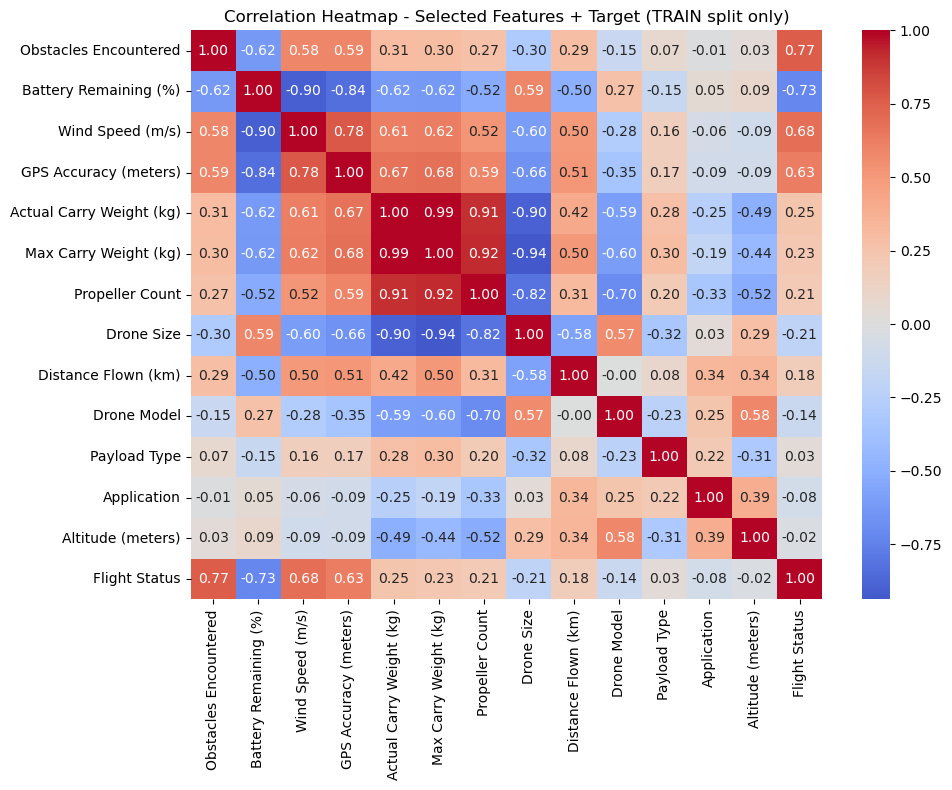

In [10]:
eda_df = X_train_raw[final_feature_order].copy()
eda_df['Flight Status'] = y_train.values

plt.figure(figsize=(10, 8))
sns.heatmap(eda_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Selected Features + Target (TRAIN split only)')
plt.tight_layout()
plt.show()


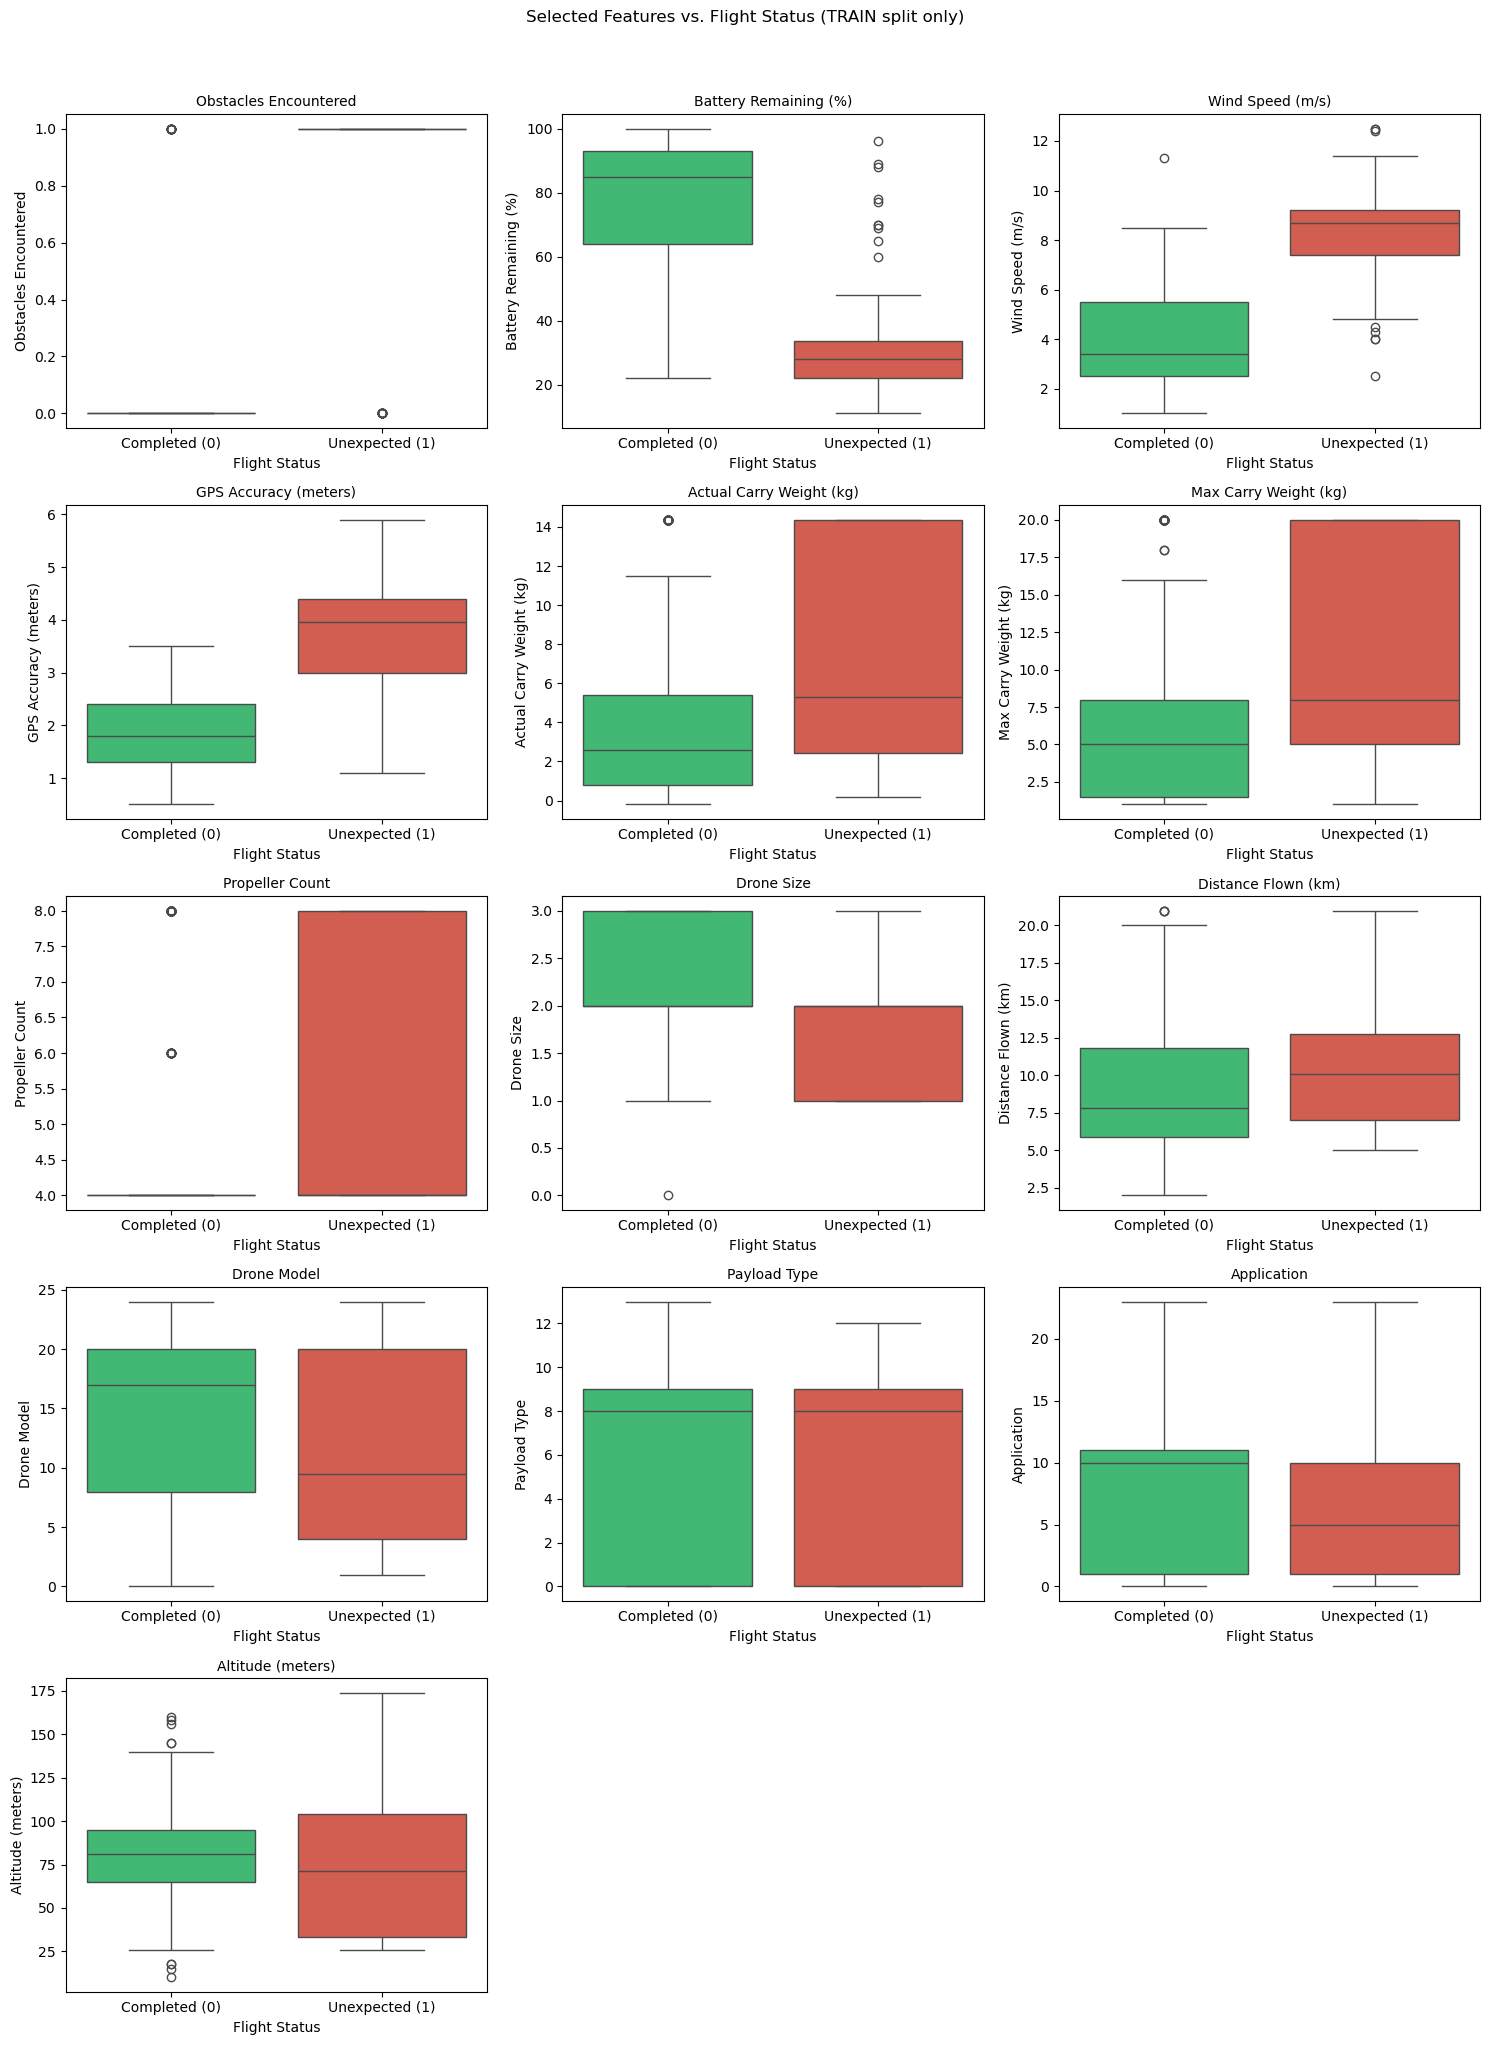

In [11]:
n_feats = len(final_feature_order)
n_cols = 3
n_rows = int(np.ceil(n_feats / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, feat in zip(axes, final_feature_order):
    sns.boxplot(data=eda_df, x='Flight Status', y=feat, hue='Flight Status',
                palette=['#2ecc71', '#e74c3c'], legend=False, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Completed (0)', 'Unexpected (1)'])
    ax.set_title(feat, fontsize=10)

for ax in axes[n_feats:]:
    ax.axis('off')

plt.suptitle('Selected Features vs. Flight Status (TRAIN split only)', y=1.02)
plt.tight_layout()
plt.show()


## PART 8: FEATURE SCALING (fit on TRAIN only)

In [12]:
X_train = X_train_raw[final_feature_order].copy()
X_test = X_test_raw[final_feature_order].copy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Scaler fitted on TRAIN only ({X_train_scaled.shape[0]} rows, {X_train_scaled.shape[1]} features).")
print(f"TEST transformed using the TRAIN-fitted scaler ({X_test_scaled.shape[0]} rows) -- "
      "no test-set statistics were used to fit the scaler.")


Scaler fitted on TRAIN only (431 rows, 13 features).
TEST transformed using the TRAIN-fitted scaler (108 rows) -- no test-set statistics were used to fit the scaler.


## PART 9: SMOTE (TRAIN ONLY)

Used here to build a single balanced training set for the baseline models
and for the final ANN. The held-out test set is never resampled. For the
*hyperparameter-tuning* stage (Part 11), SMOTE is instead applied
independently inside every cross-validation fold (see markdown there) rather
than once up front, to avoid leaking synthetic-sample information across
folds during model selection.


In [13]:
smote = SMOTE(random_state=SEED)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Training set after SMOTE: {X_train_resampled.shape[0]} samples (from {X_train_scaled.shape[0]} real samples)")
print(f"Test set (never resampled): {X_test_scaled.shape[0]} samples")
print(pd.Series(y_train_resampled).value_counts().rename('count'))


Training set after SMOTE: 650 samples (from 431 real samples)
Test set (never resampled): 108 samples
Flight Status
1    325
0    325
Name: count, dtype: int64


## PART 10: BASELINE CLASSICAL MODELS (default hyperparameters)

Trained on the SMOTE-balanced training set, evaluated once on the untouched
test set. These are the "before tuning" reference points for Part 13's
comparison.


In [14]:
baseline_models = {
    'Logistic Regression': LogisticRegression(random_state=SEED, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=SEED),
    'XGBoost': XGBClassifier(random_state=SEED, eval_metric='logloss'),
    'SVM': SVC(random_state=SEED),
}

baseline_results = {}
for name, model in baseline_models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test_scaled)
    baseline_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'Model': model,
        'Predictions': y_pred,
    }
    r = baseline_results[name]
    print(f"{name:<22s} Acc={r['Accuracy']:.4f}  Prec={r['Precision']:.4f}  Rec={r['Recall']:.4f}  F1={r['F1 Score']:.4f}")


Logistic Regression    Acc=0.9537  Prec=0.8929  Rec=0.9259  F1=0.9091


Random Forest          Acc=0.9722  Prec=0.9286  Rec=0.9630  F1=0.9455
XGBoost                Acc=0.9444  Prec=0.8182  Rec=1.0000  F1=0.9000
SVM                    Acc=0.9537  Prec=0.8929  Rec=0.9259  F1=0.9091


## PART 11: BASELINE ANN (initial configuration)

A fixed, hand-chosen architecture, evaluated the same way as the classical
baselines. This is **not** the same architecture family as the
hyperparameter-searched ANN in Part 12 -- see Part 13 for an explicit,
accurately-worded comparison.


In [15]:
initial_ann = Sequential([
    Input(shape=(X_train_resampled.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
initial_ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
initial_history = initial_ann.fit(
    X_train_resampled, y_train_resampled,
    validation_split=0.2, epochs=100, batch_size=32,
    callbacks=[early_stop], verbose=0
)

y_pred_initial_ann = (initial_ann.predict(X_test_scaled, verbose=0) > 0.5).astype(int)
baseline_results['ANN (initial configuration)'] = {
    'Accuracy': accuracy_score(y_test, y_pred_initial_ann),
    'Precision': precision_score(y_test, y_pred_initial_ann),
    'Recall': recall_score(y_test, y_pred_initial_ann),
    'F1 Score': f1_score(y_test, y_pred_initial_ann),
    'Model': initial_ann,
    'Predictions': y_pred_initial_ann,
}
r = baseline_results['ANN (initial configuration)']
print(f"ANN (initial configuration)  Acc={r['Accuracy']:.4f}  Prec={r['Precision']:.4f}  Rec={r['Recall']:.4f}  F1={r['F1 Score']:.4f}")


ANN (initial configuration)  Acc=0.9815  Prec=1.0000  Rec=0.9259  F1=0.9615


## PART 12: HYPERPARAMETER TUNING -- CLASSICAL MODELS

**Leakage fix:** SMOTE is now placed *inside* an `imblearn.pipeline.Pipeline`
together with the estimator, and that pipeline (not the estimator alone) is
what `GridSearchCV` cross-validates. This means SMOTE is fit and applied
independently within each of the 5 training folds, so synthetic samples from
one fold can never appear in another fold's validation data. `GridSearchCV`
is fit on `X_train_scaled` / `y_train` -- the *real*, un-resampled training
data -- not on the pre-resampled `X_train_resampled`.

The **Best CV F1** reported below is a cross-validation score computed
entirely on training folds; it is reported separately from, and should not
be confused with, the **held-out TEST metrics**, which come from one
evaluation of the winning pipeline against the untouched test set.


In [16]:
models_params = {
    'Logistic Regression': {
        'pipeline': ImbPipeline([('smote', SMOTE(random_state=SEED)),
                                  ('clf', LogisticRegression(max_iter=1000, random_state=SEED))]),
        'params': {'clf__C': [0.01, 0.1, 1, 10, 100], 'clf__solver': ['liblinear', 'lbfgs']}
    },
    'Random Forest': {
        'pipeline': ImbPipeline([('smote', SMOTE(random_state=SEED)),
                                  ('clf', RandomForestClassifier(random_state=SEED))]),
        'params': {'clf__n_estimators': [100, 200, 300], 'clf__max_depth': [5, 10, 15, None],
                   'clf__min_samples_split': [2, 5, 10], 'clf__min_samples_leaf': [1, 2, 4]}
    },
    'XGBoost': {
        'pipeline': ImbPipeline([('smote', SMOTE(random_state=SEED)),
                                  ('clf', XGBClassifier(eval_metric='logloss', random_state=SEED))]),
        'params': {'clf__n_estimators': [100, 200, 300], 'clf__learning_rate': [0.01, 0.05, 0.1],
                   'clf__max_depth': [3, 5, 7], 'clf__subsample': [0.8, 1.0]}
    },
    'SVM': {
        'pipeline': ImbPipeline([('smote', SMOTE(random_state=SEED)),
                                  ('clf', SVC(probability=True, random_state=SEED))]),
        'params': {'clf__C': [0.1, 1, 10, 100], 'clf__gamma': ['scale', 'auto', 0.1, 1],
                   'clf__kernel': ['rbf', 'linear']}
    }
}

tuned_results = {}

for name, cfg in models_params.items():
    print(f"\n{'=' * 60}\nTuning {name} (SMOTE applied inside each CV fold)\n{'=' * 60}")
    grid = GridSearchCV(cfg['pipeline'], cfg['params'], cv=5, scoring='f1', n_jobs=-1, verbose=1)
    grid.fit(X_train_scaled, y_train)

    best_pipeline = grid.best_estimator_
    y_pred = best_pipeline.predict(X_test_scaled)

    tuned_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'Model': best_pipeline,
        'Best Params': grid.best_params_,
        'Best CV F1': grid.best_score_,
        'Predictions': y_pred,
    }
    r = tuned_results[name]
    print(f"Best params: {r['Best Params']}")
    print(f"Best CV F1 (5-fold, train only, SMOTE inside each fold): {r['Best CV F1']:.4f}")
    print(f"HELD-OUT TEST METRICS -> Acc={r['Accuracy']:.4f}  Prec={r['Precision']:.4f}  "
          f"Rec={r['Recall']:.4f}  F1={r['F1 Score']:.4f}")



Tuning Logistic Regression (SMOTE applied inside each CV fold)
Fitting 5 folds for each of 10 candidates, totalling 50 fits


Best params: {'clf__C': 0.1, 'clf__solver': 'liblinear'}
Best CV F1 (5-fold, train only, SMOTE inside each fold): 0.9005
HELD-OUT TEST METRICS -> Acc=0.9630  Prec=0.8966  Rec=0.9630  F1=0.9286

Tuning Random Forest (SMOTE applied inside each CV fold)
Fitting 5 folds for each of 108 candidates, totalling 540 fits


Best params: {'clf__max_depth': 15, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Best CV F1 (5-fold, train only, SMOTE inside each fold): 0.9423
HELD-OUT TEST METRICS -> Acc=0.9630  Prec=0.8966  Rec=0.9630  F1=0.9286

Tuning XGBoost (SMOTE applied inside each CV fold)
Fitting 5 folds for each of 54 candidates, totalling 270 fits


Best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__subsample': 1.0}
Best CV F1 (5-fold, train only, SMOTE inside each fold): 0.9436
HELD-OUT TEST METRICS -> Acc=0.9352  Prec=0.8125  Rec=0.9630  F1=0.8814

Tuning SVM (SMOTE applied inside each CV fold)
Fitting 5 folds for each of 32 candidates, totalling 160 fits


Best params: {'clf__C': 100, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Best CV F1 (5-fold, train only, SMOTE inside each fold): 0.9273
HELD-OUT TEST METRICS -> Acc=0.9630  Prec=1.0000  Rec=0.8519  F1=0.9200


## PART 13: HYPERPARAMETER SEARCH -- ANN (searched configuration)

**Second leakage fix:** the previous version selected its "best" ANN
configuration by evaluating every candidate directly against the TEST set
and keeping whichever maximized test F1 -- which means the test set was
effectively used to choose the final model, a form of leakage through model
selection. Here, an internal validation split is carved out of the training
data (before SMOTE) specifically for choosing the winning configuration; the
test set is not touched anywhere in this search.

Once the winning hyperparameters are identified, the model is refit on the
*full* SMOTE-balanced training set and evaluated **once** on the real test
set, exactly like the classical models above.


In [17]:
X_ann_tr, X_ann_val, y_ann_tr, y_ann_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=SEED, stratify=y_train
)
X_ann_tr_res, y_ann_tr_res = SMOTE(random_state=SEED).fit_resample(X_ann_tr, y_ann_tr)

param_grid = {
    'units_layer1': [32, 64, 128],
    'units_layer2': [16, 32, 64],
    'dropout_rate': [0.2, 0.3, 0.4],
    'learning_rate': [0.001, 0.01],
    'batch_size': [16, 32]
}

best_val_f1 = -1
best_ann_params = {}
total_combinations = len(list(ParameterGrid(param_grid)))
print(f"Testing {total_combinations} ANN configurations "
      "(selection based on the internal VALIDATION split, NOT the test set)...")

for i, params in enumerate(ParameterGrid(param_grid)):
    candidate = Sequential([
        Input(shape=(X_ann_tr_res.shape[1],)),
        Dense(params['units_layer1'], activation='relu'),
        Dropout(params['dropout_rate']),
        Dense(params['units_layer2'], activation='relu'),
        Dropout(params['dropout_rate']),
        Dense(1, activation='sigmoid')
    ])
    candidate.compile(optimizer=Adam(learning_rate=params['learning_rate']),
                       loss='binary_crossentropy', metrics=['accuracy'])
    es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    candidate.fit(X_ann_tr_res, y_ann_tr_res, validation_split=0.2, epochs=100,
                  batch_size=params['batch_size'], callbacks=[es], verbose=0)

    y_val_pred = (candidate.predict(X_ann_val, verbose=0) > 0.5).astype(int)
    val_f1 = f1_score(y_ann_val, y_val_pred)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_ann_params = params
        print(f"  [{i + 1}/{total_combinations}] New best (validation F1={val_f1:.4f}): {params}")

print("\nBest ANN configuration found (by internal validation F1, NOT test F1):")
print(best_ann_params, "-> validation F1 =", f"{best_val_f1:.4f}")


Testing 108 ANN configurations (selection based on the internal VALIDATION split, NOT the test set)...


  [1/108] New best (validation F1=0.8780): {'batch_size': 16, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'units_layer1': 32, 'units_layer2': 16}


  [11/108] New best (validation F1=0.8837): {'batch_size': 16, 'dropout_rate': 0.2, 'learning_rate': 0.01, 'units_layer1': 32, 'units_layer2': 32}


  [21/108] New best (validation F1=0.9000): {'batch_size': 16, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'units_layer1': 32, 'units_layer2': 64}


  [25/108] New best (validation F1=0.9302): {'batch_size': 16, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'units_layer1': 128, 'units_layer2': 16}



Best ANN configuration found (by internal validation F1, NOT test F1):
{'batch_size': 16, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'units_layer1': 128, 'units_layer2': 16} -> validation F1 = 0.9302


In [18]:
best_ann_model = Sequential([
    Input(shape=(X_train_resampled.shape[1],)),
    Dense(best_ann_params['units_layer1'], activation='relu'),
    Dropout(best_ann_params['dropout_rate']),
    Dense(best_ann_params['units_layer2'], activation='relu'),
    Dropout(best_ann_params['dropout_rate']),
    Dense(1, activation='sigmoid')
])
best_ann_model.compile(optimizer=Adam(learning_rate=best_ann_params['learning_rate']),
                        loss='binary_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
best_ann_history = best_ann_model.fit(
    X_train_resampled, y_train_resampled,
    validation_split=0.2, epochs=100, batch_size=best_ann_params['batch_size'],
    callbacks=[es], verbose=0
)

y_pred_best_ann = (best_ann_model.predict(X_test_scaled, verbose=0) > 0.5).astype(int)
tuned_results['ANN (hyperparameter-searched configuration)'] = {
    'Accuracy': accuracy_score(y_test, y_pred_best_ann),
    'Precision': precision_score(y_test, y_pred_best_ann),
    'Recall': recall_score(y_test, y_pred_best_ann),
    'F1 Score': f1_score(y_test, y_pred_best_ann),
    'Model': best_ann_model,
    'Best Params': best_ann_params,
    'Predictions': y_pred_best_ann,
}
r = tuned_results['ANN (hyperparameter-searched configuration)']
print(f"FINAL ANN -- HELD-OUT TEST METRICS -> Acc={r['Accuracy']:.4f}  Prec={r['Precision']:.4f}  "
      f"Rec={r['Recall']:.4f}  F1={r['F1 Score']:.4f}")


FINAL ANN -- HELD-OUT TEST METRICS -> Acc=0.9722  Prec=1.0000  Rec=0.8889  F1=0.9412


## PART 14: FINAL MODEL COMPARISON AND SELECTION

Comparing the "initial configuration" ANN against the "hyperparameter-searched
configuration" ANN is **not** a same-architecture before/after-tuning
comparison -- the initial ANN has 3 hidden layers (64-32-16, fixed dropout
0.3) while the searched ANN has 2 hidden layers with searched widths and
dropout. Wording below reflects this explicitly.


In [19]:
comparison_rows = []
for name, r in baseline_results.items():
    comparison_rows.append({'Stage': 'Baseline / initial configuration', 'Model': name,
                             'Accuracy': r['Accuracy'], 'Precision': r['Precision'],
                             'Recall': r['Recall'], 'F1 Score': r['F1 Score']})
for name, r in tuned_results.items():
    comparison_rows.append({'Stage': 'Tuned / searched configuration', 'Model': name,
                             'Accuracy': r['Accuracy'], 'Precision': r['Precision'],
                             'Recall': r['Recall'], 'F1 Score': r['F1 Score']})

comparison_df = pd.DataFrame(comparison_rows)
comparison_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']] = comparison_df[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']].round(4)
print(comparison_df.to_string(index=False))

best_classical_name = max(
    [n for n in tuned_results if not n.startswith('ANN')],
    key=lambda n: tuned_results[n]['Accuracy']
)
best_classical_model = tuned_results[best_classical_name]['Model']
print(f"\nBest classical model (by held-out test accuracy): {best_classical_name} "
      f"(Accuracy={tuned_results[best_classical_name]['Accuracy']:.4f})")

final_model_name = max(tuned_results, key=lambda n: tuned_results[n]['Accuracy'])
print(f"Final selected model for the Streamlit app (by held-out test accuracy): {final_model_name} "
      f"(Accuracy={tuned_results[final_model_name]['Accuracy']:.4f})")


                           Stage                                       Model  Accuracy  Precision  Recall  F1 Score
Baseline / initial configuration                         Logistic Regression    0.9537     0.8929  0.9259    0.9091
Baseline / initial configuration                               Random Forest    0.9722     0.9286  0.9630    0.9455
Baseline / initial configuration                                     XGBoost    0.9444     0.8182  1.0000    0.9000
Baseline / initial configuration                                         SVM    0.9537     0.8929  0.9259    0.9091
Baseline / initial configuration                 ANN (initial configuration)    0.9815     1.0000  0.9259    0.9615
  Tuned / searched configuration                         Logistic Regression    0.9630     0.8966  0.9630    0.9286
  Tuned / searched configuration                               Random Forest    0.9630     0.8966  0.9630    0.9286
  Tuned / searched configuration                                     XGB

In [20]:
for name, r in tuned_results.items():
    cm = confusion_matrix(y_test, r['Predictions'])
    print(f"\nConfusion matrix - {name}:")
    print(pd.DataFrame(cm, index=['Actual: Completed', 'Actual: Unexpected'],
                        columns=['Predicted: Completed', 'Predicted: Unexpected']))



Confusion matrix - Logistic Regression:
                    Predicted: Completed  Predicted: Unexpected
Actual: Completed                     78                      3
Actual: Unexpected                     1                     26

Confusion matrix - Random Forest:
                    Predicted: Completed  Predicted: Unexpected
Actual: Completed                     78                      3
Actual: Unexpected                     1                     26

Confusion matrix - XGBoost:
                    Predicted: Completed  Predicted: Unexpected
Actual: Completed                     75                      6
Actual: Unexpected                     1                     26

Confusion matrix - SVM:
                    Predicted: Completed  Predicted: Unexpected
Actual: Completed                     81                      0
Actual: Unexpected                     4                     23

Confusion matrix - ANN (hyperparameter-searched configuration):
                    Predicted: Comple

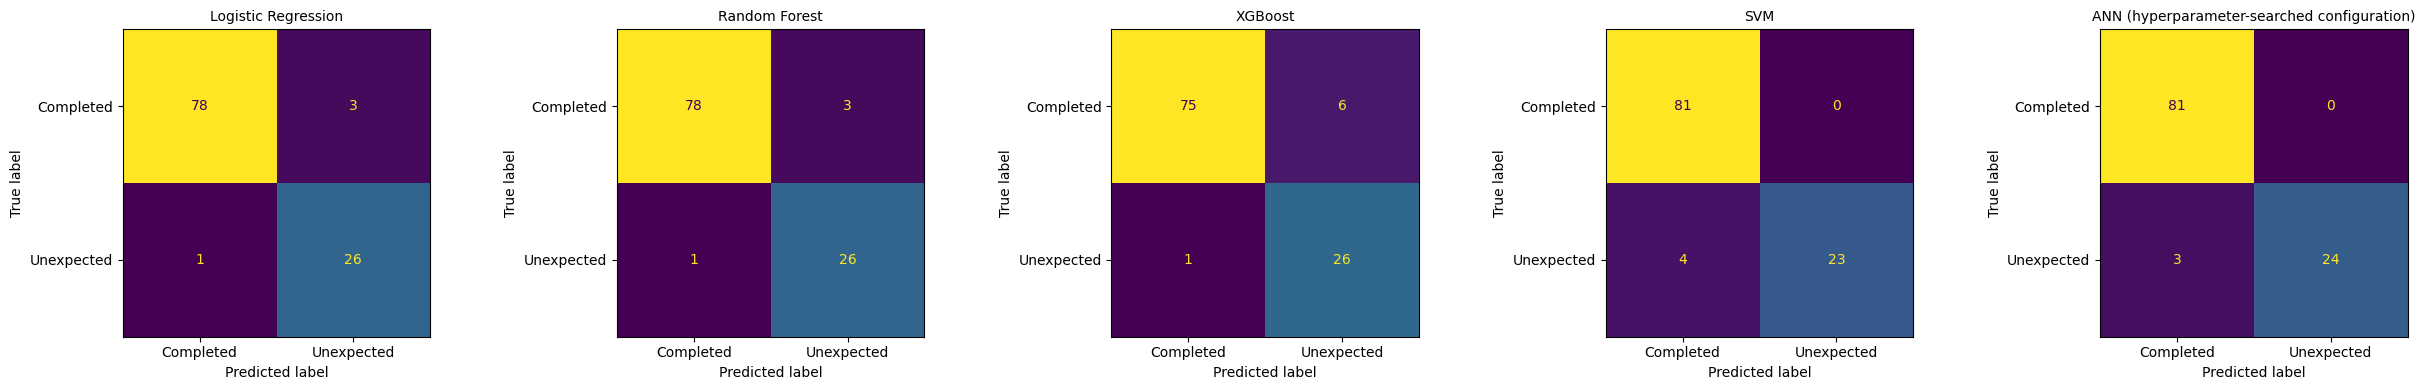

In [21]:
fig, axes = plt.subplots(1, len(tuned_results), figsize=(5 * len(tuned_results), 4))
for ax, (name, r) in zip(axes, tuned_results.items()):
    cm = confusion_matrix(y_test, r['Predictions'])
    ConfusionMatrixDisplay(cm, display_labels=['Completed', 'Unexpected']).plot(ax=ax, colorbar=False)
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.show()


## PART 15: SHAP EXPLAINABILITY (final ANN)

Uses `X_test_scaled` (the real, untouched test set) purely for explanation
purposes -- this happens after all model selection is finished and does not
influence any modeling decision.


PermutationExplainer explainer:   1%|          | 1/108 [00:00<?, ?it/s]

PermutationExplainer explainer:   3%|▎         | 3/108 [00:10<00:10, 10.32it/s]

PermutationExplainer explainer:   5%|▍         | 5/108 [00:11<00:16,  6.34it/s]

PermutationExplainer explainer:   6%|▌         | 6/108 [00:11<00:17,  5.92it/s]

PermutationExplainer explainer:   6%|▋         | 7/108 [00:11<00:17,  5.63it/s]

...

PermutationExplainer explainer:  99%|█████████▉| 107/108 [00:34<00:00,  4.65it/s]

PermutationExplainer explainer: 100%|██████████| 108/108 [00:35<00:00,  4.76it/s]

PermutationExplainer explainer: 109it [00:35,  4.99it/s]                         

PermutationExplainer explainer: 109it [00:35,  3.07it/s]


C:\Users\eys20\AppData\Local\Temp\ipykernel_17208\2214553446.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_scaled, feature_names=final_feature_order)


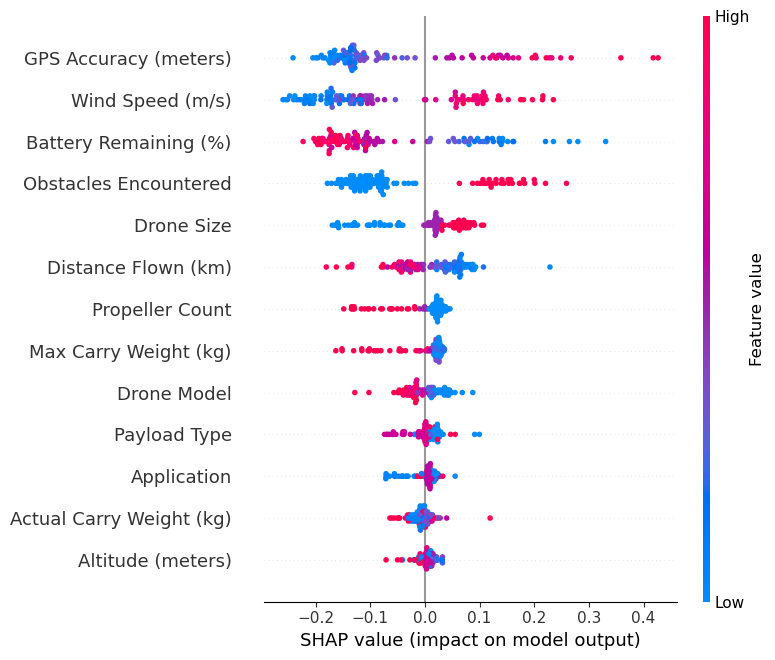

In [22]:
explainer = shap.Explainer(best_ann_model, X_train_resampled)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled, feature_names=final_feature_order)


## PART 16: SAVE CORRECTED ARTIFACTS (VALIDATION COPIES ONLY)

These are saved under **different filenames** so the current production
artifacts used by the Streamlit app (`ann2_model.h5`, `scaler2.pkl`,
`encoders.pkl`) are left untouched until the corrected pipeline has been
reviewed and explicitly approved for promotion.


In [23]:
best_ann_model.save('ann2_model_corrected.h5')
with open('scaler2_corrected.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('encoders_corrected.pkl', 'wb') as f:
    pickle.dump(encoders, f)

print("Saved VALIDATION artifacts: ann2_model_corrected.h5, scaler2_corrected.pkl, encoders_corrected.pkl")
print("Production artifacts (ann2_model.h5, scaler2.pkl, encoders.pkl) were NOT modified.")


Saved VALIDATION artifacts: ann2_model_corrected.h5, scaler2_corrected.pkl, encoders_corrected.pkl
Production artifacts (ann2_model.h5, scaler2.pkl, encoders.pkl) were NOT modified.


## PART 17: VALIDATE THE CORRECTED ARTIFACTS

In [24]:
loaded_model = tf.keras.models.load_model('ann2_model_corrected.h5')
with open('scaler2_corrected.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)
with open('encoders_corrected.pkl', 'rb') as f:
    loaded_encoders = pickle.load(f)

print("Loaded ANN input shape:", loaded_model.input_shape)
print("Loaded scaler expects", loaded_scaler.n_features_in_, "features")
print("Loaded encoders keys:", list(loaded_encoders.keys()))

assert loaded_model.input_shape[-1] == 13, "ANN input dimension is not 13"
assert loaded_scaler.n_features_in_ == 13, "Scaler does not expect 13 features"
assert set(loaded_encoders.keys()) == set(MODEL_CATEGORICAL_COLS), "Encoder keys do not match modeling categorical columns"

sample_raw = X_test_raw.iloc[[0]][final_feature_order].copy()
sample_scaled = loaded_scaler.transform(sample_raw)
sample_pred = loaded_model.predict(sample_scaled, verbose=0)[0][0]
print(f"\nSample end-to-end prediction (probability of 'Landed Unexpectedly'): {sample_pred:.4f}")
print("Corrected artifacts loaded, dimension-checked, and successfully produced a prediction.")


Loaded ANN input shape: (None, 13)
Loaded scaler expects 13 features
Loaded encoders keys: ['Drone Size', 'Drone Model', 'Payload Type', 'Application']



Sample end-to-end prediction (probability of 'Landed Unexpectedly'): 0.0000
Corrected artifacts loaded, dimension-checked, and successfully produced a prediction.
